# Deep Learning Midterms - Question 2 [2B]
>  by Anastasia Putri Hartanti

the library used in every kernel will be imported in the kernels itself

## We are going to utilize GPU to accelerate the process

In [1]:
import torch

def print_cuda_devices():
    if torch.cuda.is_available():
        device_count = torch.cuda.device_count()
        print(f"Number of CUDA devices available: {device_count}")

        for i in range(device_count):
            device = torch.cuda.get_device_name(i)
            print(f"Device {i}: {device}")
    else:
        print("CUDA is not available.")

# Call the function to print CUDA device information
print_cuda_devices()


Number of CUDA devices available: 1
Device 0: NVIDIA GeForce MX450


# Question 2

## 1. Data Loading, Exploration, and Preprocessing
> [LO 3, 5 poin] Lakukan eksplorasi terhadap data tersebut dengan melihat histogram warnanya
dan lakukan proses augmentasi data jika diperlukan. Dan kemudian lakukan resize resolusi
gambar menjadi 224 x 224. Pisahkan dataset menjadi 80% training set, 10% validation set dan
10% test set.




*   For the data loading, i downloaded my dataset as a zip file, then i uploaded the dataset to GitHub, to further ease the uploading process
*   The link that i took from github ([this one](https://github.com/anastasiahrtn/mydeeplearningexam-midterms_2/blob/main/Dataset.zip)) directs to an auto-download page, which will directly download the

### 1.1 Setting Up the File Directories + Data Loading

> We can either download the data, unzip it, and put it in the same folder as our .ipynb file, or download it using path, requsts, and zipfile to download, extract, and create folders for each train, test, and validation data

In [2]:
import requests # to get the file from my githib
import zipfile # to unzip the file
from pathlib import Path # to make a standard directory of traininga and testing data

# setting up path for the data folder
data_path = Path("data/")
default_path = data_path / "fruitsdata"

# seeing if the directory has existed
if not default_path.is_dir():
    print(f"Did not find {default_path} directory, creating one...")
    default_path.mkdir(parents=True, exist_ok=True)
else:
    print(f"{default_path} directory exists.")

# downloading the fruitsdata
if not (default_path / "fruitsdata.zip").is_file():
    with open(default_path / "fruitsdata.zip", "wb") as f:
        request = requests.get("https://github.com/anastasiahrtn/mydeeplearningexam-midterms_2/raw/main/Dataset.zip") # updated link
        print("Downloading fruitsdata...")
        f.write(request.content)

    # unzipping the fruitsdata
    with zipfile.ZipFile(default_path / "fruitsdata.zip", "r") as zip_ref:
        print("Unzipping fruitsdata...")
        zip_ref.extractall(default_path)

Did not find data/fruitsdata directory, creating one...
Unzipping fruitsdata...


### 1.2. Pre-Augmented Data Visualization

We are going to visualize the RGB values of all the data, after only resizing the images to 224*224

#### a. Turning All of the Data into Tensors

using a very simple transform which simply resizes the image

In [3]:
import torch
from torchvision import transforms
from torchvision import datasets

# creating the transform function
simple_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor() # turning the images to tensors
])

all_tensor = datasets.ImageFolder(root = default_path,
                                  transform = simple_transform, #the transform for the data
                                  target_transform = None) # the transform for the data label

tensor_sample, _ = all_tensor[20]

tensor_sample.shape

torch.Size([3, 224, 224])

The shape of the tensor represents (C,H,W) - or color_channel, height, and width

#### b. Creating the functions

In order to plot the RGB composition of the data, we are going to create a function that follows these steps:
1. loops to add the total values of each R, G, and B and put it in a variable each
2. plots the variables

In [4]:
import torch
import matplotlib.pyplot as plt

def plotRGB(data_tensor, data_name):
    # getting the length of the data
    n_data = len(data_tensor)

    # initializing the variables that will store the values r, g, and b
    r_sum = 0
    g_sum = 0
    b_sum = 0

    # loopcount = 0

    for i in range(n_data):
        # the default data_tensor[x] data type is tuple from the ImageFolder data_tensor, 
        # hence we need to turn it into tensors first
        img_tensor , _ = data_tensor[i]

        # getting the sum for each R, G, B
        r_sum =  r_sum + img_tensor[0, :, :].sum()
        g_sum =  g_sum + img_tensor[1, :, :].sum()
        b_sum =  b_sum + img_tensor[2, :, :].sum()

        #loopcount += 1   <-- utility variable to see howmany times the loop is done in one go

    # getting values for the plot
    values = [r_sum, g_sum, b_sum]
    labels = ["red", "green", "blue"]
    colors = ["red", "green", "blue"]

    plt.figure(figsize=(10, 8))
    plt.bar(labels, values, color = colors)
    plt.title(f"The RGB Values of {data_name}")
    plt.xlabel("color channels")
    plt.ylabel("values")
    plt.show

    #print(loopcount)

#### c. Ploting the data

out of curiosity, i added a few lines of code using the `time` library, to the plotting of the train data, to track how long does it takes to run the function above for 1600 tensors :D 

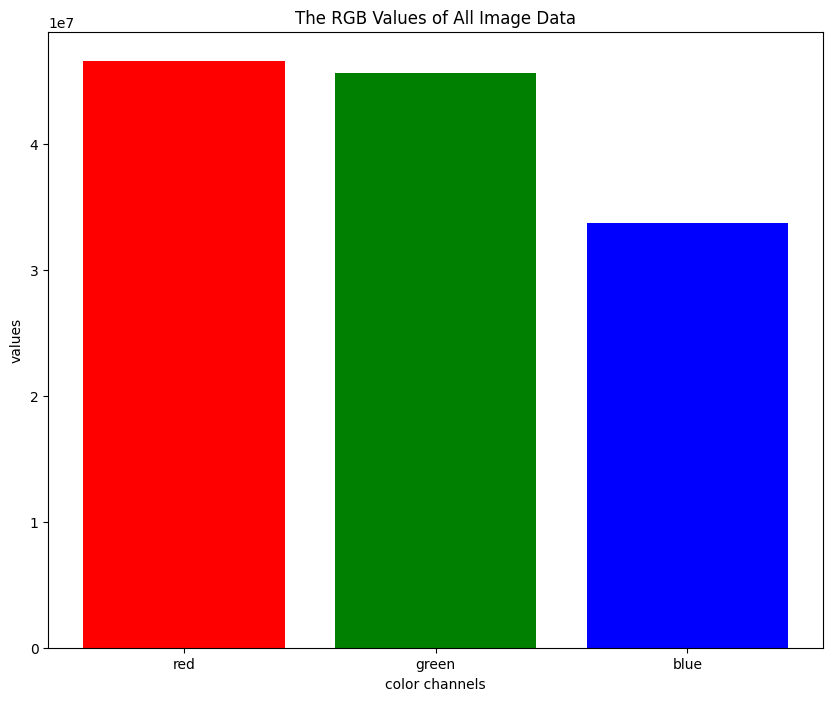

In [5]:
import time

start_time = time.time()

plotRGB(all_tensor, "All Image Data")

end_time = time.time()

execution_time = end_time - start_time

In [6]:
execution_time

14.022162437438965

### 1.3 Splitting the Data into Train, Test, and Validation Data


##### a. Splitting the data

*   Train - 80%
*   Test - 10%
*   Validation - 10%

In [7]:
import random as rd # to randomise the 80-10-10 proportion for each training, testing, and validation
import shutil # to copy the images to the desired folder

rd.seed(20)

# a. defining paths for train, test, adn validation data (val)
train_path = default_path / "train"
test_path = default_path / "test"
val_path = default_path / "val"

# b. creating subdirectories for train, test, and validation
for path in [train_path, test_path, val_path]:
    if not path.is_dir():
        path.mkdir(parents=True, exist_ok=True)

# c. listing all of the images in the dataset folder
all_images = list(default_path.glob('*/*.jpg'))  # Assuming all images are in jpg format

# d. shuffling the images
rd.shuffle(all_images)

# e. defining the number of images of each set
total_images = len(all_images)
train_split = int(0.8 * total_images)
test_split = int(0.1 * total_images)

# f. assigning the images to each set - still in path format
train_images = all_images[:train_split]
test_images = all_images[train_split:train_split + test_split]
val_images = all_images[train_split + test_split:]

# g. moving the images to their set folders
for src, dest in [(train_images, train_path), (test_images, test_path), (val_images, val_path)]:
    for img in src:
        class_folder = img.parent.name
        dest_class_path = dest / class_folder
        dest_class_path.mkdir(parents=True, exist_ok=True)
        shutil.copy(img, dest_class_path)

print("data splitting has been completed")


data splitting has been completed


##### b. Counting the Images in Each Train, Test, and Validation Subfolders
to ensure that it fulfills the percentages

In [8]:
train_list = list(train_path.glob('*/*.jpg'))
train_count = len(train_list)

test_list = list(test_path.glob('*/*.jpg'))
test_count = len(test_list)

val_list = list(val_path.glob('*/*.jpg'))
val_count = len(val_list)

train_count, test_count, val_count

(1280, 160, 160)

it fullfils the percentage :D

#### c. Utility Code: Deleting Previously Created Folders
> **ONLY RUN THE NEXT BLOCK OF CODE IF THERE IS ANY MISTAKE IN THE PREVIOUS BLOCKS OF CODE**

In [9]:
# # Define the path to the directory you want to delete
# data_path = Path("data_2/fruitsdata")

# # Check if the directory exists before deleting
# if data_path.exists():
#     print(f"Deleting {data_path} directory...")

#     # Delete the directory and its contents
#     shutil.rmtree(data_path)

#     print(f"{data_path} directory deleted successfully!")
# else:
#     print(f"{data_path} directory does not exist.")

### 1.4 Data Transforming and Preprocessing

> transforming the image data to tensors, in order for it to be processed by PyTorch

##### a. Creating a Transform

for this project, we are going to use multiple transforms, which are:

*   Resize (to 224*244)
*   RandomVerticalFlip
*   RandomHorizontalFlip
*   RandomRotation

> visualizations for every augmentation, click [here](https://pytorch.org/vision/0.15/auto_examples/plot_transforms.html)

RandomVerticalFlip, RandomHorizontalFlip, and RandomRotation are all used because fruit images can be absolutely random, it can be taken up-side-down, or even tilted. to cover the possibility of those images, we are going to utilize the three augmentation tools.

In [9]:
import torch
from torchvision import transforms
torch.manual_seed(20) # for the randomization in augmentation and random horizontal flip

# augmentations are only done in training datasets
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(25), # applies random rotation up to 25 degrees
    transforms.RandomHorizontalFlip(), # applies horizontal flip randomly
    transforms.RandomVerticalFlip(), # applies vertical flip randomly
    transforms.ToTensor() # turning the images to tensors
])

# we dont need to augment both test and validation, but we have to ensure that the size is still 224*224
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

#### b. Transformed Image Visualization and Comparison

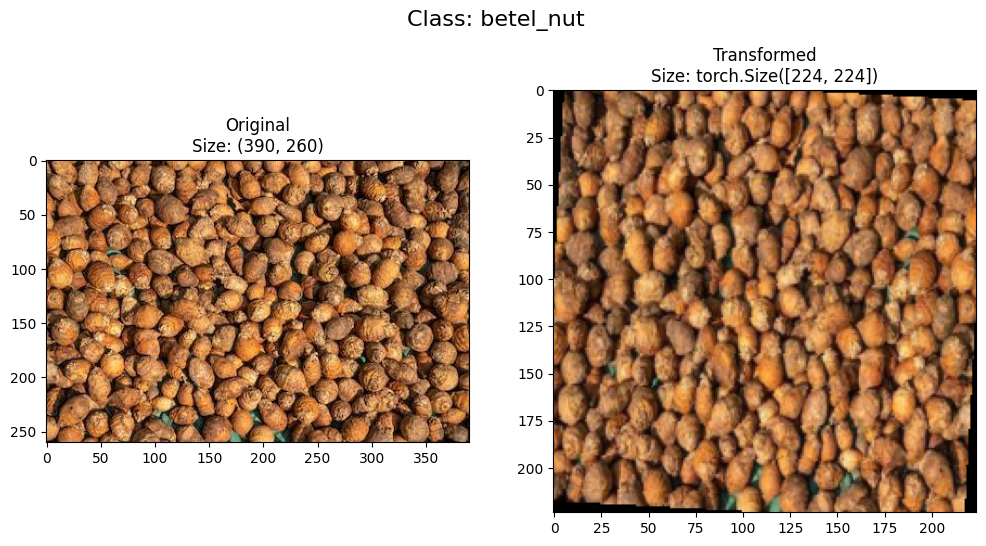

In [11]:
import random
import matplotlib.pyplot as plt
from PIL import Image

def plot_transformed_images(image_paths, data_transform, n=1, seed=20):
    random.seed(seed)

    random_image_paths = random.sample(image_paths, k=n)

    for image_path in random_image_paths:
        with Image.open(image_path) as f:
            fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))

            # plotting the original image in ax (axis 0)
            ax[0].imshow(f)
            ax[0].set_title(f"Original\nSize: {f.size}")
            ## ax[0].axis("off")

            # applying the transformation plotting the transformed image in ax (axis 1)
            transformed_image = data_transform(f)
            ax[1].imshow(transformed_image.permute(1, 2, 0))# changes the order of tensor [(C,H,W)->(H,C,W)]
                                    ## because the default for PyTorch is (C,H,W) but matplotlib is (H,C,W)
            ax[1].set_title(f"Transformed\nSize: {transformed_image.shape[1:]}")
            ## ax[1].axis("off")

            fig.suptitle(f"Class: {image_path.parent.stem}", fontsize=16)
            plt.show()


plot_transformed_images(image_paths=list(train_path.glob('*/*.jpg')), data_transform=train_transform)

The train transform seem to work well in transforming and augmenting the images.

#### c. Transforming the Data into Usable DataLoaders

##### i. Transforming Image Data -> Tensors

In [10]:
from torchvision import datasets

train_tensor = datasets.ImageFolder(root = train_path,
                                  transform = train_transform, #the transform for the data
                                  target_transform = None) # the transform for the data label

test_tensor = datasets.ImageFolder(root = test_path,
                                  transform = test_transform, #the transform for the data
                                  target_transform = None) # the transform for the data label

val_tensor = datasets.ImageFolder(root = val_path,
                                  transform = val_transform, #the transform for the data
                                  target_transform = None) # the transform for the data label

train_tensor, test_tensor, val_tensor

(Dataset ImageFolder
     Number of datapoints: 1280
     Root location: data/fruitsdata/train
     StandardTransform
 Transform: Compose(
                Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
                RandomRotation(degrees=[-25.0, 25.0], interpolation=nearest, expand=False, fill=0)
                RandomHorizontalFlip(p=0.5)
                RandomVerticalFlip(p=0.5)
                ToTensor()
            ),
 Dataset ImageFolder
     Number of datapoints: 160
     Root location: data/fruitsdata/test
     StandardTransform
 Transform: Compose(
                Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
                ToTensor()
            ),
 Dataset ImageFolder
     Number of datapoints: 160
     Root location: data/fruitsdata/val
     StandardTransform
 Transform: Compose(
                Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
                ToTensor()
       

##### ii. Getting Class Names

In [13]:
# as list
class_name = train_tensor.classes
class_name

['banana', 'betel_nut', 'bitter_gourd', 'black_berry']

In [14]:
# as dictionary
class_dict = train_tensor.class_to_idx
class_dict

{'banana': 0, 'betel_nut': 1, 'bitter_gourd': 2, 'black_berry': 3}

##### iii. Printing the Shape of the Tensors

In [15]:
import torch

# train_data, test_data, and val_data are all sets of tensors
# to see the shape of an individual tensor, we have to take a sample for each data
train_sample = train_tensor[0]
test_sample = test_tensor[0]
val_sample = val_tensor[0]

# extracting the image and label tensors
train_image_tensor, train_label_tensor = train_sample
test_image_tensor, test_label_tensor = test_sample
val_image_tensor, val_label_tensor = val_sample

# printing the tensor shapes
train_image_tensor.shape, test_image_tensor.shape, val_image_tensor.shape


(torch.Size([3, 224, 224]),
 torch.Size([3, 224, 224]),
 torch.Size([3, 224, 224]))

In [16]:
test_tensor[7]

(tensor([[[0.6706, 0.6431, 0.6275,  ..., 0.7059, 0.7137, 0.7451],
          [0.6510, 0.6235, 0.6157,  ..., 0.6941, 0.7020, 0.7333],
          [0.6471, 0.6235, 0.6157,  ..., 0.6824, 0.6902, 0.7216],
          ...,
          [0.0431, 0.0078, 0.0118,  ..., 0.4196, 0.4157, 0.3804],
          [0.0706, 0.0157, 0.0196,  ..., 0.4196, 0.4196, 0.3961],
          [0.0941, 0.0275, 0.0235,  ..., 0.4157, 0.4275, 0.4118]],
 
         [[0.6627, 0.6353, 0.6196,  ..., 0.6745, 0.6824, 0.7137],
          [0.6431, 0.6157, 0.6078,  ..., 0.6627, 0.6706, 0.7020],
          [0.6392, 0.6157, 0.6078,  ..., 0.6510, 0.6588, 0.6902],
          ...,
          [0.0392, 0.0039, 0.0078,  ..., 0.3333, 0.3294, 0.2941],
          [0.0667, 0.0118, 0.0157,  ..., 0.3333, 0.3333, 0.3098],
          [0.0902, 0.0235, 0.0196,  ..., 0.3294, 0.3451, 0.3294]],
 
         [[0.6745, 0.6471, 0.6314,  ..., 0.6627, 0.6706, 0.7020],
          [0.6549, 0.6275, 0.6196,  ..., 0.6510, 0.6588, 0.6902],
          [0.6510, 0.6275, 0.6196,  ...,

Shown above is one of the examples of the tensors

##### iv. Transfroming Tensors -> DataLoaders

> The dataset that we are using is a pretty large dataset of 1600 images. Using DataLoaders, we can utilize batch processing to boost the speed of our model creation

>> **the batch size**

*   I tried setting the n_workers to 2, and it took me about 5 minutes to train the model. When I set the n_worker to 16, given that I have 16 CPU cores in my device, it took over 10 minutes to train the model. This may happen due to bottleneck in the data flow.


---



**Training Dataset**
```
Batch Size = 16
Number of Workers = 16
```

**Test and Validation Dataset**
```
Batch Size = 16
Number of Workers = 16
```

> we will be using 16 batch size because in my previous tries, i tried using a large number of batch size and my laptop crashed :')

In [11]:
# the reccomended number of workers is depended on the num of cpu cores available
import os
os.cpu_count()

8

In [12]:
from torch.utils.data import DataLoader


train_dataloader = DataLoader(dataset = train_tensor,
                              batch_size = 8,
                              num_workers = 2,
                              shuffle = True)

test_dataloader = DataLoader(dataset = test_tensor,
                              batch_size = 8,
                              num_workers = 2,
                              shuffle = False)

val_dataloader = DataLoader(dataset = val_tensor,
                              batch_size = 8,
                              num_workers = 2,
                              shuffle = False)

train_dataloader, test_dataloader, val_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x7f49e0448410>,
 <torch.utils.data.dataloader.DataLoader at 0x7f49e0505d50>)

### 1.5 Post-Augmentation Visualization

We are going to be reusing the plotRGB function from 1.2b

##### a. Training Dataset

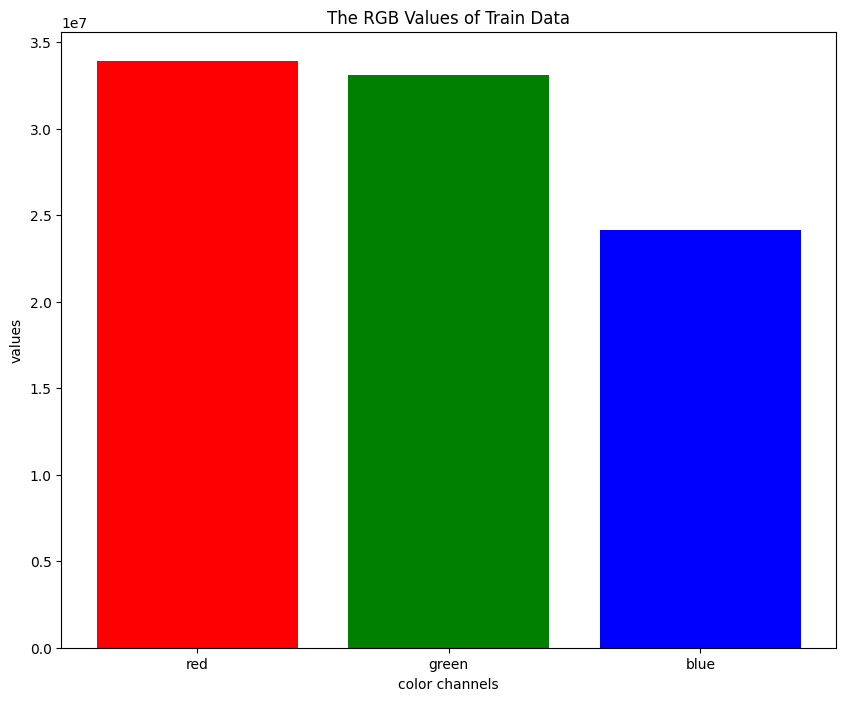

In [19]:
plotRGB(train_tensor, "Train Data")

##### b. Test Dataset

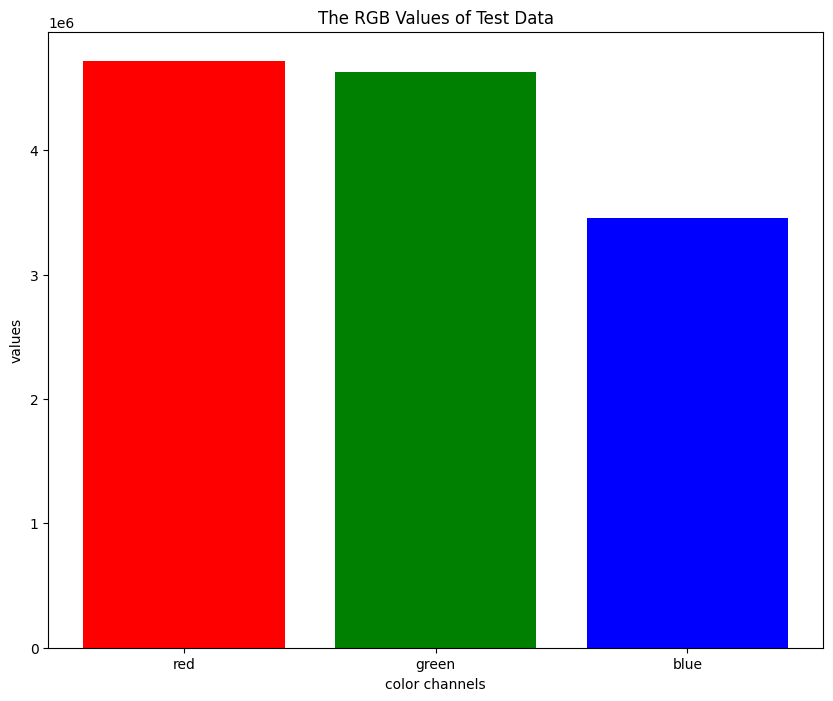

In [20]:
plotRGB(test_tensor, "Test Data")

#### c. Validation Dataset

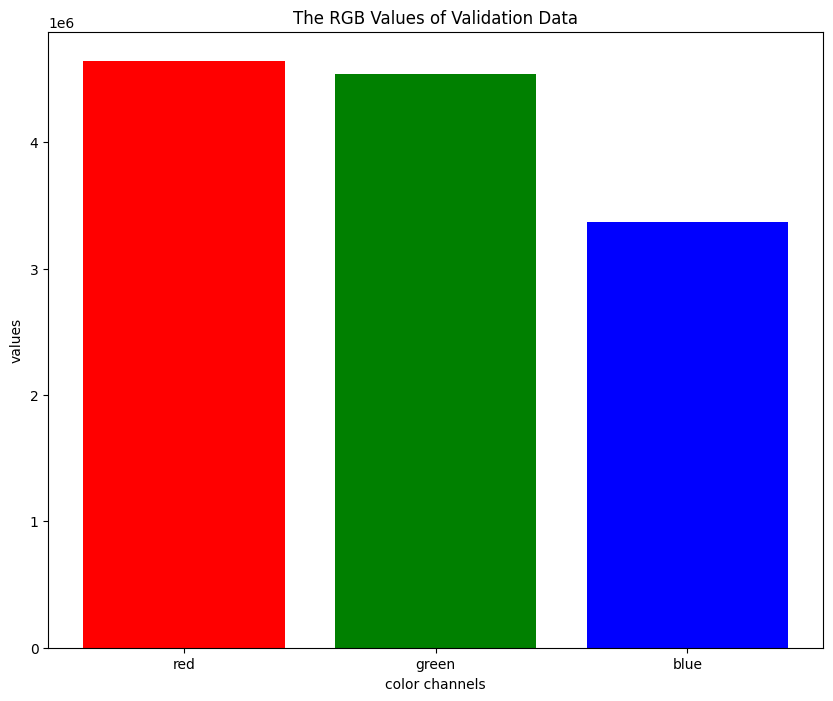

In [21]:
plotRGB(val_tensor, "Validation Data")

## 2. Challenges in Dataset

## 3. Model Creation
> [LO 3, 15 poin] Buatlah arsitektur baseline sesuai dengan gambar arsitektur VGG-16 berikut ini:
(Catatan: Activation function tiap hidden layer menggunakan ReLU). Jelaskan mengenai model
pretained dari VGG-16 yang digunakan dan metode fine-tuning yang dilakukan.

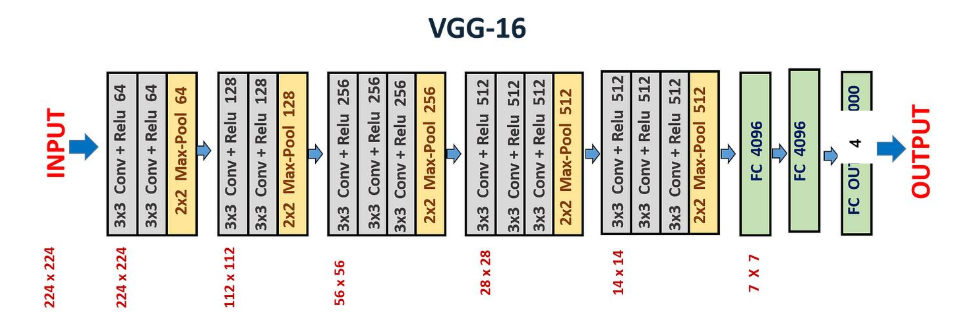

### 3.1 Background Theories

#### a. CNN with ReLU Explanation

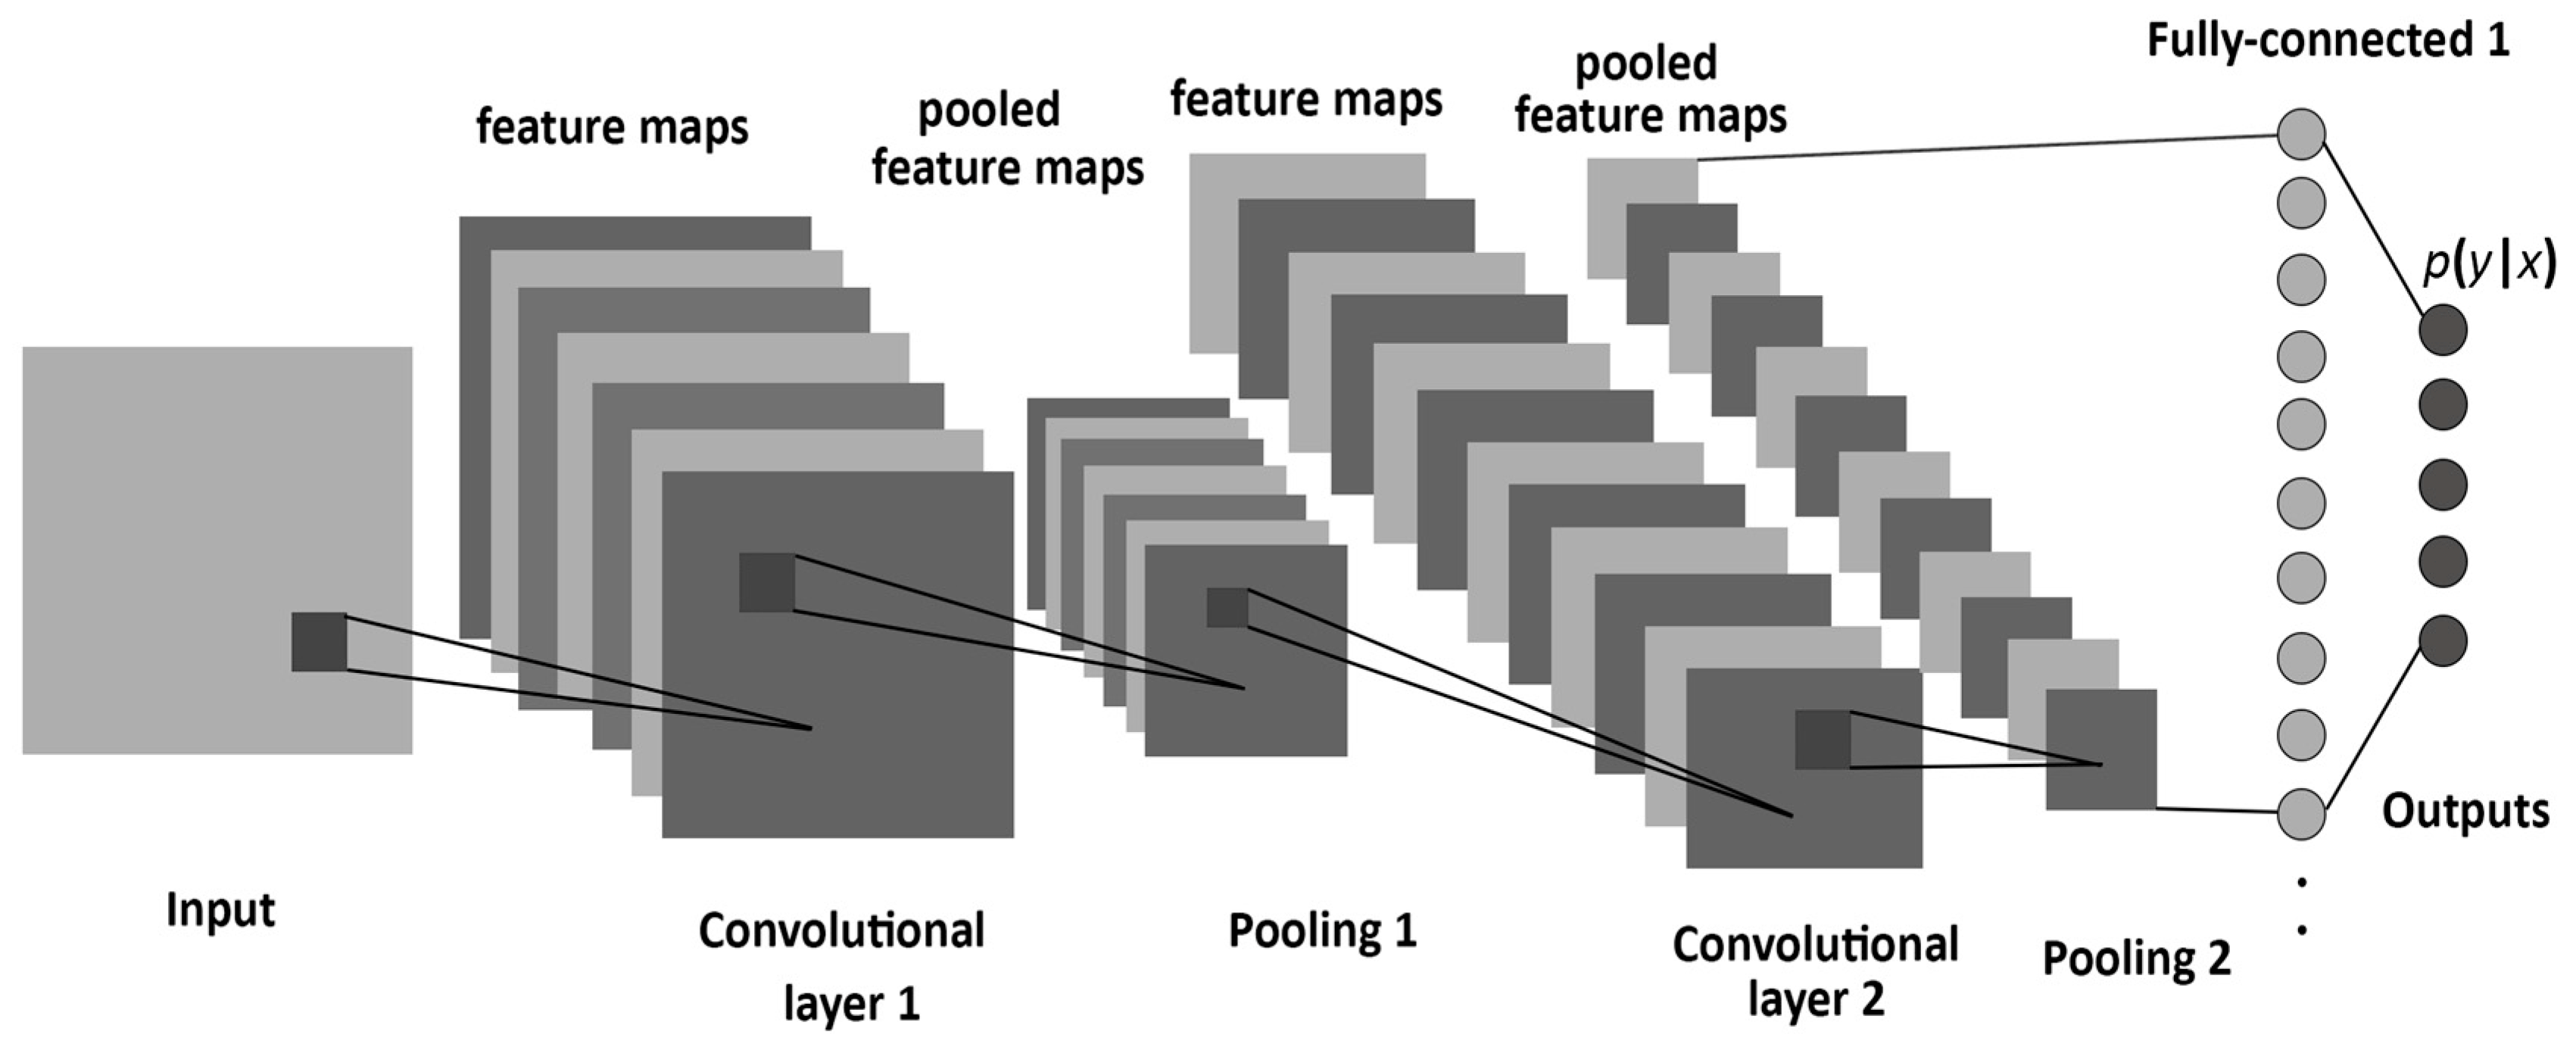

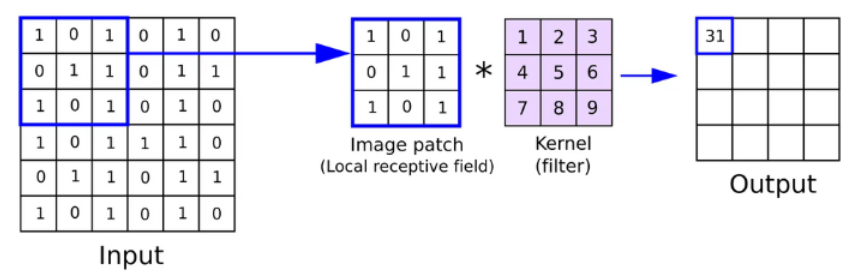

#### b. Max Pooling Explained

> `nn.MaxPool2d(kernel_size=2, stride=2)`
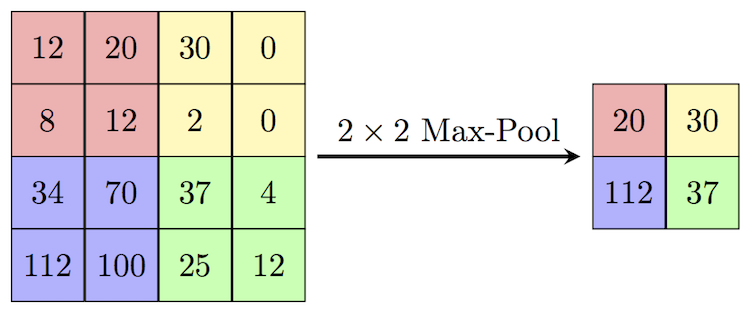

therefore, the default stride value equals to its kernel size

### 3.2 Setting Up Cuda Device

In [13]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

### [NOT USED] Model Building
> i didnt know that vgg16 has its own pretrained model so i created my own model here :') 

In [23]:
# import torch.nn as nn
# import time

# class myvgg16(nn.Module):
 
#     def __init__(self) -> None:
#         super().__init__()
#         self.conv_block_1 = nn.Sequential(
#             nn.Conv2d(in_channels = 3, # input channels
#                       out_channels = 64, # output channels 
#                       kernel_size=3, # how big is the cnn kernel?
#                       stride=1, # the number of pixels the kernel moves everytime it works
#                       padding=1), # options = "valid" (no padding) or "same" (output has same shape as input) or int for specific number 
#             nn.ReLU(),
#             nn.Conv2d(in_channels=64, 
#                       out_channels=64,
#                       kernel_size=3, 
#                       stride=1,
#                       padding=1),
#             nn.ReLU(),
#             nn.MaxPool2d(kernel_size=2,
#                          stride=2) 
#         )

#         self.conv_block_2 = nn.Sequential(
#             nn.Conv2d(in_channels = 64, 
#                       out_channels = 128, 
#                       kernel_size=3, 
#                       stride=1, 
#                       padding=1), 
#             nn.ReLU(),
#             nn.Conv2d(in_channels=128, 
#                       out_channels=128,
#                       kernel_size=3, 
#                       stride=1,
#                       padding=1),
#             nn.ReLU(),
#             nn.MaxPool2d(kernel_size=2,
#                          stride=2) 
#         )

#         self.conv_block_3 = nn.Sequential(
#             nn.Conv2d(in_channels = 128, 
#                       out_channels = 256, 
#                       kernel_size=3, 
#                       stride=1, 
#                       padding=1), 
#             nn.ReLU(),
#             nn.Conv2d(in_channels=256, 
#                       out_channels=256,
#                       kernel_size=3, 
#                       stride=1,
#                       padding=1),
#             nn.ReLU(),
#             nn.Conv2d(in_channels=256, 
#                       out_channels=256,
#                       kernel_size=3, 
#                       stride=1,
#                       padding=1),
#             nn.ReLU(),
#             nn.MaxPool2d(kernel_size=2,
#                          stride=2) 
#         )

#         self.conv_block_4 = nn.Sequential(
#             nn.Conv2d(in_channels = 256, 
#                       out_channels = 512, 
#                       kernel_size=3, 
#                       stride=1, 
#                       padding=1), 
#             nn.ReLU(),
#             nn.Conv2d(in_channels=512, 
#                       out_channels=512,
#                       kernel_size=3, 
#                       stride=1,
#                       padding=1),
#             nn.ReLU(),
#             nn.Conv2d(in_channels=512, 
#                       out_channels=512,
#                       kernel_size=3, 
#                       stride=1,
#                       padding=1),
#             nn.ReLU(),
#             nn.MaxPool2d(kernel_size=2,
#                          stride=2) 
#         )

#         self.conv_block_5 = nn.Sequential(
#             nn.Conv2d(in_channels = 512, 
#                       out_channels = 512, 
#                       kernel_size=3, 
#                       stride=1, 
#                       padding=1), 
#             nn.ReLU(),
#             nn.Conv2d(in_channels=512, 
#                       out_channels=512,
#                       kernel_size=3, 
#                       stride=1,
#                       padding=1),
#             nn.ReLU(),
#             nn.Conv2d(in_channels=512, 
#                       out_channels=512,
#                       kernel_size=3, 
#                       stride=1,
#                       padding=1),
#             nn.ReLU(),
#             nn.MaxPool2d(kernel_size=2,
#                          stride=2) 
#         )

#         self.fc_block_6 = nn.Linear(512, # n of input layers  
#                                     4096) # n of output layers
        
#         self.fc_block_7 = nn.Linear(4096, 
#                                     4096)
        
#         # the last fully connected (FC) block is the final classifier
#         self.classifier = nn.Linear(4096,  
#                                     4)
    
#     def forward(self, x: torch.Tensor):
#         x = self.conv_block_1(x)
#         #print(f"Block 1 output: {x.shape}")
#         x = self.conv_block_2(x)
#         #print(f"Block 2 output: {x.shape}")
#         x = self.conv_block_3(x)
#         #print(f"Block 3 output: {x.shape}")
#         x = self.conv_block_4(x)
#         #print(f"Block 4 output: {x.shape}")
#         x = self.conv_block_5(x)
#         #print(f"Block 5 output: {x.shape}")
#         x = self.fc_block_6(x)
#         #print(f"Block 6 output: {x.shape}")
#         x = self.fc_block_7(x)
#         #print(f"Block 7 output: {x.shape}")

#         x = self.classifier(x)
#         #print(f"Classifier block output: {x.shape}")
#         return x
#         # return self.classifier(self.conv_block_2(self.conv_block_1(x))) # <- leverage the benefits of operator fusion


# torch.manual_seed(20)
# model_0 = vgg16().to(device)
# model_0

In [14]:
import torch

# Check if CUDA is available
if torch.cuda.is_available():
    # Select GPU device
    device = torch.device("cuda:0")
    
    # Get GPU memory usage
    allocated = torch.cuda.memory_allocated(device)
    cached = torch.cuda.memory_reserved(device)
    
    print(f"Allocated: {allocated / (1024 ** 3):.2f} GB")
    print(f"Cached: {cached / (1024 ** 3):.2f} GB")
else:
    print("CUDA is not available.")


Allocated: 0.00 GB
Cached: 0.00 GB


In [25]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")


### 3.3 Model Declaration

In [15]:
import torchvision.models as models
import torch.nn as nn

model_finetune = models.vgg16(pretrained=True)

# since there are 4 classes in our datasetm we have to modify the classifier layer 
# to produce an output of 4
num_ftrs = model_finetune.classifier[6].in_features
model_finetune.classifier[6] = nn.Linear(num_ftrs, 4)


/home/wbchn/miniconda3/envs/PyTorch-DLN/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/wbchn/miniconda3/envs/PyTorch-DLN/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /home/wbchn/.cache/torch/hub/checkpoints/vgg16-397923af.pth
 47%|████▋     | 249M/528M [10:10<11:23, 428kB/s] 


KeyboardInterrupt: 

### 3.4 Model Training

In [28]:
import torch
import torch.nn as nn
import torch.optim as optim
import time

# move the model to cuda device
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model_finetune.to(device)

# setting the loss optimizer
criterion = nn.CrossEntropyLoss() # loss function definition
optimizer = optim.SGD(model_finetune.parameters(), lr=0.001, momentum=0.9) # used for weight updating 
            # fine-tuning most of the time uses the SGD optimizer


# << to record the time before training >>
start_time = time.time()

# seting the model to training mode
model_finetune.train()

# number of epochs for training
num_epochs = 5 # epoch refers to the number of times the model will do forward and backward training

# the training loop
for epoch in range(num_epochs):
    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0
    
    n_loop = 0

    for img_batch, label_batch in train_dataloader:

        # to ensure that this loop iterates based on the number of data in train_dataloader
        n_loop +=1

        # moving the image data to the CUDA device
        img_batch, label_batch = img_batch.to(device), label_batch.to(device)
        
        # forward passing
        outputs = model_finetune(img_batch)
        
        # loss calculation
        loss = criterion(outputs, label_batch)
        
        # setting the gradients to zero, preparing for the next iteration
        optimizer.zero_grad() # so that it wont accumulate with the gradients from the previous iteration
        
        # backward pass
        loss.backward()
        
        # optimizing
        optimizer.step()
        
        # stats updates
        running_loss += loss.item() * img_batch.size(0)
        _, predicted = torch.max(outputs, 1)
        correct_predictions += (predicted == label_batch).sum().item()
        total_samples += img_batch.size(0)
    
    # getting the average loss and accuracy for the epoch
    epoch_loss = running_loss / total_samples
    epoch_accuracy = correct_predictions / total_samples
    
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}, Accuracy: {epoch_accuracy:.4f}")
    print(f"number of loops : {n_loop}")


# << to record the time after training >>
end_time = time.time()
ft_train_time = end_time - start_time


print('Finished Training')

KeyboardInterrupt: 

In [ ]:
print(f"Execution time: {ft_train_time} seconds")

Execution time: 296.94657731056213 seconds


### 3.5 Testing the Model on `test_dataloader` 

In [ ]:
model_finetune.eval()  # setting the model to evaluation mode
correct_predictions = 0
total_samples = 0 

# since we wont be needing to compute the gradient for testing
with torch.no_grad():
    for img_batch, label_batch in test_dataloader:
        # moving the data to the CUDA device
        img_batch, label_batch = img_batch.to(device), label_batch.to(device)
        
        # forward pass
        outputs = model_finetune(img_batch)
        
        # getting predicted labels
        _, predicted = torch.max(outputs, 1)
        
        # statistic updates
        correct_predictions += (predicted == label_batch).sum().item()
        total_samples += label_batch.size(0)

# accuracy calculation
accuracy = correct_predictions / total_samples
print(f"Test Accuracy: {accuracy * 100:.2f}%")


## 4. Training

In [ ]:
import torch
print(torch.hub.get_dir())


C:\Users\ROG ZEPHYRUS/.cache\torch\hub


In [ ]:

# to record the time before training
start_time = time.time()


# to record the time after training
execution_time = end_time - start_time

end_time = time.time()

print(f"Execution time: {execution_time} seconds")


In [ ]:
test_tensor.__name__

AttributeError: 'ImageFolder' object has no attribute '__name__'

In [ ]:
import time

start_time = time.time()



end_time = time.time()

execution_time = end_time - start_time
print(f"Execution time: {execution_time} seconds")

Execution time: 0.0 seconds
